In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

# 1. 加载数据 (假设你已经下载了 GLD.csv 和 GDX.csv)
tickers = ['EWA', 'EWC']
data = yf.download(tickers, start="2006-05-22", end="2012-01-01")

/tmp/ipykernel_601087/3884247649.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2006-05-22", end="2012-01-01")
[*********************100%***********************]  2 of 2 completed


In [26]:
data = data['Close'].dropna()

In [27]:
data

Ticker,EWA,EWC
Date,,
2006-05-22,8.487020,15.623443
2006-05-23,8.602097,15.636873
2006-05-24,8.499352,15.489160
2006-05-25,8.610316,16.053139
2006-05-26,8.667857,16.194132
...,...,...
2011-12-23,11.761446,19.565983
2011-12-27,11.739859,19.499283
2011-12-28,11.394406,19.195415


In [30]:
# 3. 协整检验 (对应原代码中的 cadf 函数)
# coint 函数返回：t-stat, p-value, critical values
score, pvalue, crit_value = coint(data[tickers[0]], data[tickers[1]])

print(f"CADF t-statistic: {score:.4f}")
print(f"Critical Values (1%, 5%, 10%): {crit_value}")

print(f"P-value: {pvalue:.4f}")

CADF t-statistic: -3.1253
Critical Values (1%, 5%, 10%): [-3.9042021  -3.34045456 -3.04745079]
P-value: 0.0833


In [32]:
# 4. 计算对冲比例 (Hedge Ratio) - 使用 OLS 回归
y = data[tickers[0]]
x = data[tickers[1]]
x = sm.add_constant(x) # 添加截距项
model = sm.OLS(y, x).fit()

hedge_ratio = model.params[tickers[1]]
z = model.resid # 这里的 z 就是残差，即价差 spread

print(f"Hedge Ratio (beta): {hedge_ratio:.4f}")

Hedge Ratio (beta): 0.6252


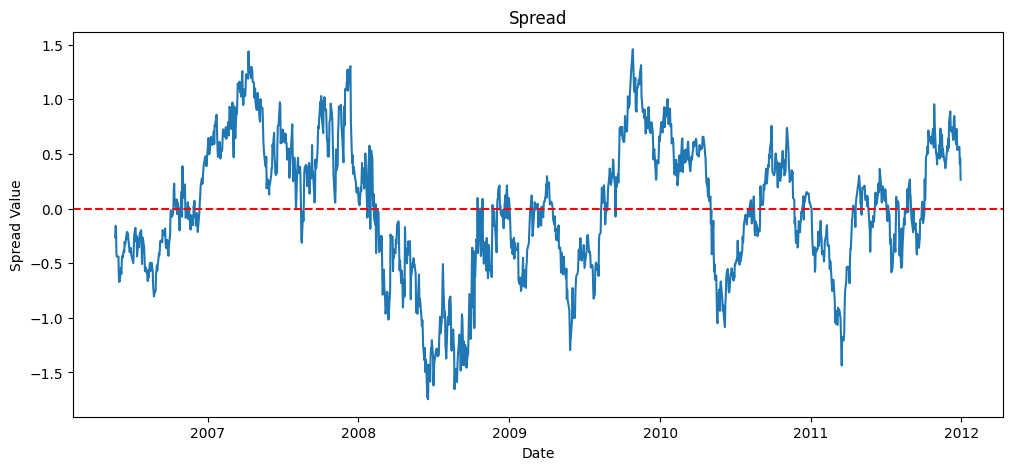

In [34]:
# 5. 绘图 (对应原代码中的 plot(z))
plt.figure(figsize=(12, 5))
plt.plot(z)
plt.axhline(z.mean(), color='red', linestyle='--')
plt.title('Spread')
plt.ylabel('Spread Value')
plt.xlabel('Date')
plt.show()